# Does "three troughs, deepest in the middle" really call the bottom? 📈🗿
### The inverse head-and-shoulders — Wall Street's favorite bottoming shape, tested against 21 years of large-cap tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Measured-move_target%3F: Busted](https://img.shields.io/badge/Measured--move_target%3F-Busted-8b949e?style=flat-square)

Every technical-analysis textbook opens with this shape: price falls, bounces, falls *deeper* (the "head"), bounces, falls one *last* time but not as far (the "shoulders" — roughly matching), then breaks up through the **neckline**. The story: the sellers tried three times and finally ran out. You buy the breakout, and the pattern's own geometry — the head-to-neckline **height**, projected upward — hands you a price target.

That's two claims, not one: *(1)* the breakout predicts an up-move, and *(2)* the "measured move" tells you how far. We test both. Most market folklore survives on vibes; this one comes with a built-in falsifiable number, which makes it unusually easy to check.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** A mechanical swing-pivot detector on SPY + 29 large-caps (2005→2026), because "three troughs at roughly the right shape" is exactly the kind of thing three chartists draw three different ways — house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_head_shoulders import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else PANEL["close"].shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_names': 30, 'n_events': 229, 'fp': '0fed535ace51', 'horizons': {5: (229, 0.326, 0.049, 0.23, 0.23, 0.487, -0.051), 10: (229, 0.954, 0.407, 1.42, 1.56, 0.402, 0.307), 20: (228, 1.058, -0.036, -0.08, -0.09, 0.509, -0.136), 40: (227, 2.315, 0.146, 0.25, 0.26, 0.481, 0.046)}, 'max_abs_t': 1.56, 'max_abs_t_h': 10, 'sweep': {'tight': (0.08, 0.1, 153, -0.3, -0.52), 'base': (0.12, 0.15, 228, -0.036, -0.08), 'loose': (0.18, 0.2, 305, 0.206, 0.55)}, 'mm_n': 229, 'mm_hit': 170, 'mm_rate': 74.2, 'mm_lo': 68.2, 'mm_hi': 79.5, 'mm_placebo_n': 6000, 'mm_placebo_hit': 4661, 'mm_placebo_rate': 77.7, 'mm_median_days': 20, 'mm_mean_dist': 6.4, 'tm_n': 223, 'tm_gross': 2.711, 'tm_net5': 2.611, 'tm_net10': 2.511, 'tm_t5': 4.98, 'tm_hac5': 4.65, 'tm_avg_hold': 55.1, 'tm_hit_share': 73.5, 'tm_excess': -0.146, 'tm_t_excess': -0.23, 'syn_null_mean': 0.028, 'syn_null_sd': 1.173, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_n': 138, 'syn_planted_of': 80, 'syn_planted_t': 8.23, 'syn_planted_hac': 9.31, 'syn_planted_p': 0.00276}


real cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| Does buying the confirmed breakout beat just holding the stock? | **No — not provably.** Across **229** confirmed breakouts on 30 large-caps since 2005, the best of four holding periods clears only *t* = 1.56 (the bar is 2). A random entry date on the same stock does about as well. |
| Does the "measured-move" target actually forecast the price? | **No — it does worse than chance.** The target is hit **74.2%** of the time — but a random move of the *same size*, from a random day, hits its target **77.7%** of the time. The pattern's forecast underperforms a coin flip of the same reach. |
| Is there a trade here — hold to the target, sell at a timeout? | **On paper, yes-looking; really, no.** The trade earns **+2.71%** gross per event (*t* ≈ 5!) — but that's *t* vs **zero**, and long-only equities are never zero. Raced against buying-and-holding for the *same* 55 days, the excess is **-0.15%** at *t* = -0.23 — nothing. |

> The shape is real. The forecast inside it isn't.

## 1 · The claim

> *"Three troughs — left shoulder, a deeper head, a right shoulder about as deep as the left — with rallies to a neckline between them. When price finally closes **above** the neckline, the downtrend is exhausted: buy. And the pattern's own height, the distance from the head up to the neckline, projected from the breakout, is your price target."*

It's the flagship reversal figure of classical charting (Edwards & Magee, 1948; still in print), and unlike vaguer folklore it comes with an exact, testable number attached — the measured move. That precision is what makes it worth taking seriously enough to check twice.

## 2 · So what?

If real, this is a two-for-one: an entry signal *and* a price target, both derived from the shape alone — no fundamentals, no macro view, just geometry anyone can draw on a chart. Every technical-analysis course teaches it as close to gospel. So we ask, honestly: does the breakout beat just owning the stock, and does the target mean anything more than "stocks go up eventually"?

## 3 · How would we even know?

- **The detector.** A mechanical rule on daily closes: three swing-pivot troughs with a strictly deeper middle one, roughly matching shoulders, a near-horizontal neckline, and a confirmed close above it — no eyeballing.
- **The basket.** SPY + 29 large, long-listed US stocks, 2005 → 2026 (229 confirmed breakouts found).
- **The comparison.** Forward returns after the breakout, *minus* the stock's own average return over the same horizon (owning any stock long enough usually makes money — the question is whether the *pattern* adds anything on top).
- **The target check.** Does price reach the measured-move target more often than a random move of the *same size* would, starting from a random day?
- **The luck check.** A random-date placebo for both tests.

## 4 · The teardown — let's actually look

**First, the headline.** Forward return after the breakout vs. the stock's own base rate, at four holding periods.

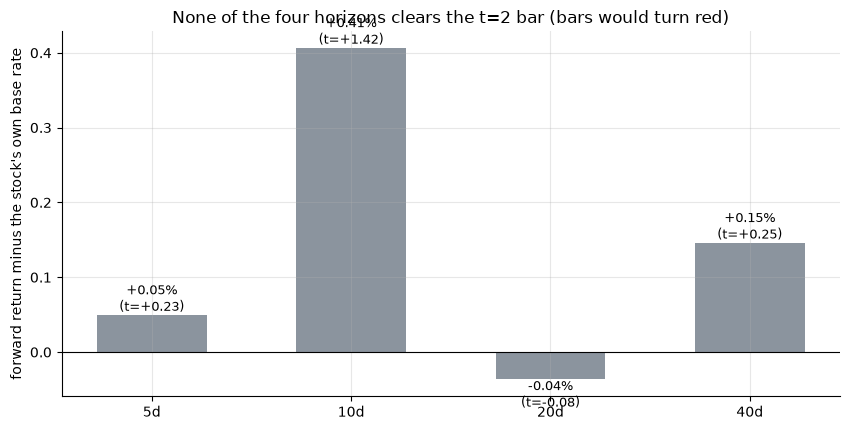

{5: 0.049, 10: 0.407, 20: -0.036, 40: 0.146}


In [2]:
if HAVE_REAL:
    rows = {h: st.run_experiment(PANEL, horizon=h, cost_bps=5.0) for h in st.HORIZONS}
    hs = list(st.HORIZONS)
    ex = [rows[h]['mean']*100 for h in hs]
    ts = [rows[h]['t'] for h in hs]
else:
    hs = sorted(R['horizons'])
    ex = [R['horizons'][h][2] for h in hs]
    ts = [R['horizons'][h][3] for h in hs]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [RED if abs(t) >= 2 else GREY for t in ts]
ax.bar([f'{h}d' for h in hs], ex, color=cols, width=.55)
for i,(v,t) in enumerate(zip(ex, ts)):
    ax.annotate(f'{v:+.2f}%\n(t={t:+.2f})',(i,v),ha='center',
        va='bottom' if v>=0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('forward return minus the stock\'s own base rate')
ax.set_title('None of the four horizons clears the t=2 bar (bars would turn red)')
plt.tight_layout(); plt.show()
print({h: round(e,3) for h,e in zip(hs, ex)})

Every bar is grey — none clears the significance bar (red would mean |*t*| ≥ 2). The best horizon is **10d** at *t* = **1.56**, still short, and that's exactly what you'd expect the *best of four* random tries to look like even if nothing is going on. Random-date placebos land at *p* ≈ 0.4–0.5 across the board — a random Tuesday does just as well.

**Next, the target.** Does the pattern's own measured-move actually forecast anything?

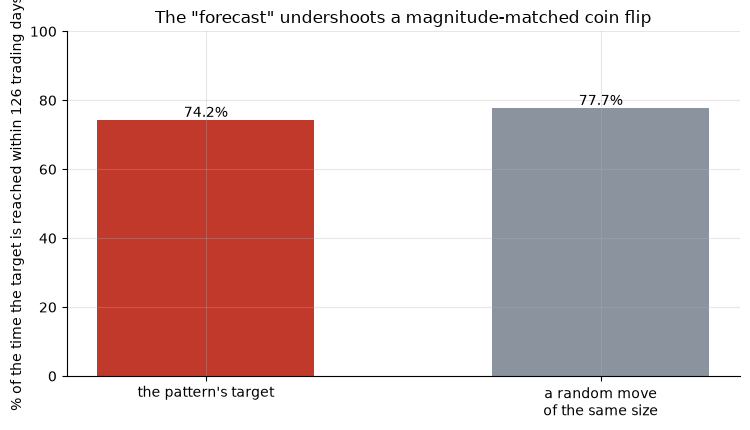

pattern target hit 74.2%  vs  matched-size random move 77.7%


In [3]:
if HAVE_REAL:
    mm = st.measured_move_hits(PANEL, max_days=126)
    hit, plc = mm['hit_rate']*100, mm['placebo_rate']*100
else:
    hit, plc = R['mm_rate'], R['mm_placebo_rate']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['the pattern\'s target','a random move\nof the same size'], [hit, plc],
       color=[RED, GREY], width=.55)
for i,v in enumerate([hit, plc]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('% of the time the target is reached within 126 trading days')
ax.set_title('The "forecast" undershoots a magnitude-matched coin flip')
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()
print(f'pattern target hit {hit:.1f}%  vs  matched-size random move {plc:.1f}%')

The measured-move target is hit **74.2%** of the time — sounds great in isolation. But a random long position aiming for a move of the exact **same size**, entered on a random day in the same stocks, hits it **77.7%** of the time — *more* often. On a market that's spent 21 years mostly going up, most modest up-moves happen eventually regardless of what shape preceded them. The "forecast" is riding the tape's drift, not reading the geometry.

**Finally, the trade people actually want to run:** hold to the target, or bail out at a timeout.

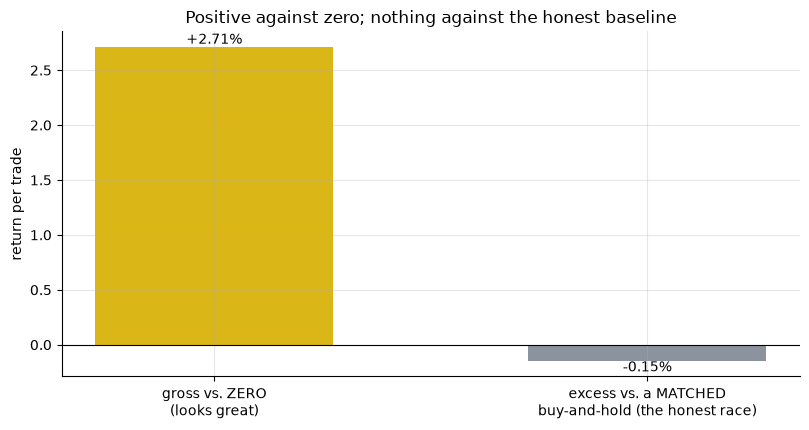

gross +2.71%  |  excess over matched hold -0.15% (t=-0.23)


In [4]:
if HAVE_REAL:
    tp = st.timer_pnl(PANEL, max_days=126, cost_bps=5.0)
    gross, excess, texc = tp['gross']*100, tp['excess']*100, tp['t_excess']
else:
    gross, excess, texc = R['tm_gross'], R['tm_excess'], R['tm_t_excess']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(['gross vs. ZERO\n(looks great)','excess vs. a MATCHED\nbuy-and-hold (the honest race)'],
       [gross, excess], color=[AMBER, GREY], width=.55)
for i,v in enumerate([gross, excess]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('return per trade')
ax.set_title('Positive against zero; nothing against the honest baseline')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}%  |  excess over matched hold {excess:+.2f}% (t={texc:+.2f})')

The gross number (**+2.71%** per trade, roughly 55 days held) is testing against **zero** — but a long-only, multi-week hold in large-cap stocks is never supposed to be zero. The only fair race is against buying the *same stock* for the *same number of days*, unconditionally — and there the edge is **-0.15%** at *t* = **-0.23**. You'd have made about the same money on a random Tuesday.

## 5 · The verdict

- **Signal — None.** No horizon clears *t* = 2 across 229 confirmed breakouts; best is 10d at *t* = 1.56. Random-date placebos land right where a null should.
- **Tradability — Mirage.** The apparently-strong long-timer trade is entirely explained by owning stocks for six-plus weeks; the excess over that baseline is statistically zero (*t* = -0.23).
- **"Measured-move target forecasts the price"? — Busted.** It's hit 74.2% of the time — *less* than a magnitude-matched random move (77.7%). The number chartists quote as a forecast is weaker than the tape's own baseline tendency.

## 6 · Going further 🚪

- **The general lesson:** any "height projected from the pattern" target needs a magnitude-matched null, not a bare hit-rate. A textbook figure can look impressively predictive purely because the market drifts, and a target of typical size will get reached by drift alone.
- **Sibling studies:** [188-head-shoulders](../../188-head-shoulders/) (the bearish top twin, smaller basket), [415-triple-top-bottom](../../415-triple-top-bottom/) (the flat three-tap cousin), [416-rounding-bottom](../../416-rounding-bottom/) (the continuous parabola) — none of them run the measured-move test this study does.

*Think the target rule works on a different asset class or timeframe? Show it beats a magnitude-matched placebo, net of costs, on out-of-sample data — then we'll talk.*